In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# SETTING UP NECESSARY LIBRARIES

In [2]:
!pip install -q datasets huggingface_hub
!pip install -q -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 74.7 MB/s eta 0:00:00


# Loading the Data

In [3]:
from datasets import load_dataset

dataset = load_dataset(
    "mrdbourke/FoodExtract-1k-Vision"
)

dataset

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/280M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1510 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image_name', 'food101_class_name', 'food101_split', 'image_source', 'qwen3_vl_8b_yaml_out', 'qwen3_vl_inference_time', 'output_label_json', 'is_food', 'image'],
        num_rows: 1510
    })
})

# **Inspecting The Data Content**

Dataset({
    features: ['image_id', 'image_name', 'food101_class_name', 'food101_split', 'image_source', 'qwen3_vl_8b_yaml_out', 'qwen3_vl_inference_time', 'output_label_json', 'is_food', 'image'],
    num_rows: 1510
})

Columns:
['image_id', 'image_name', 'food101_class_name', 'food101_split', 'image_source', 'qwen3_vl_8b_yaml_out', 'qwen3_vl_inference_time', 'output_label_json', 'is_food', 'image']
Number of samples: 1510

Food distribution:
is_food
1    1010
0     500
Name: count, dtype: int64

Image sources:
image_source
food101     1010
manual       250
internet     250
Name: count, dtype: int64

Food101 splits:
food101_split
train    757
test     253
Name: count, dtype: int64
Image ID: 3233632
Image name: 3233632.jpg
Food101 class: cheese_plate
Food101 split: train
Source: food101
Is food: 1

Qwen output:
point_of_view: 45-degree
dishes:
  - cheese plate
food_items:
  - cheese wedge
  - toast
  - herb garnish
  - dipping sauce
drink_items: []
containers_and_utensils:
  - white p

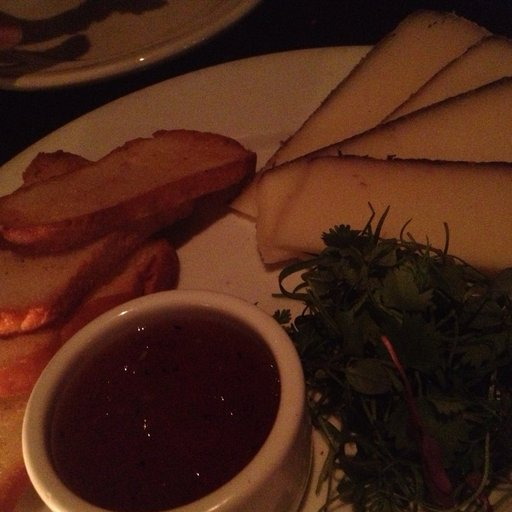

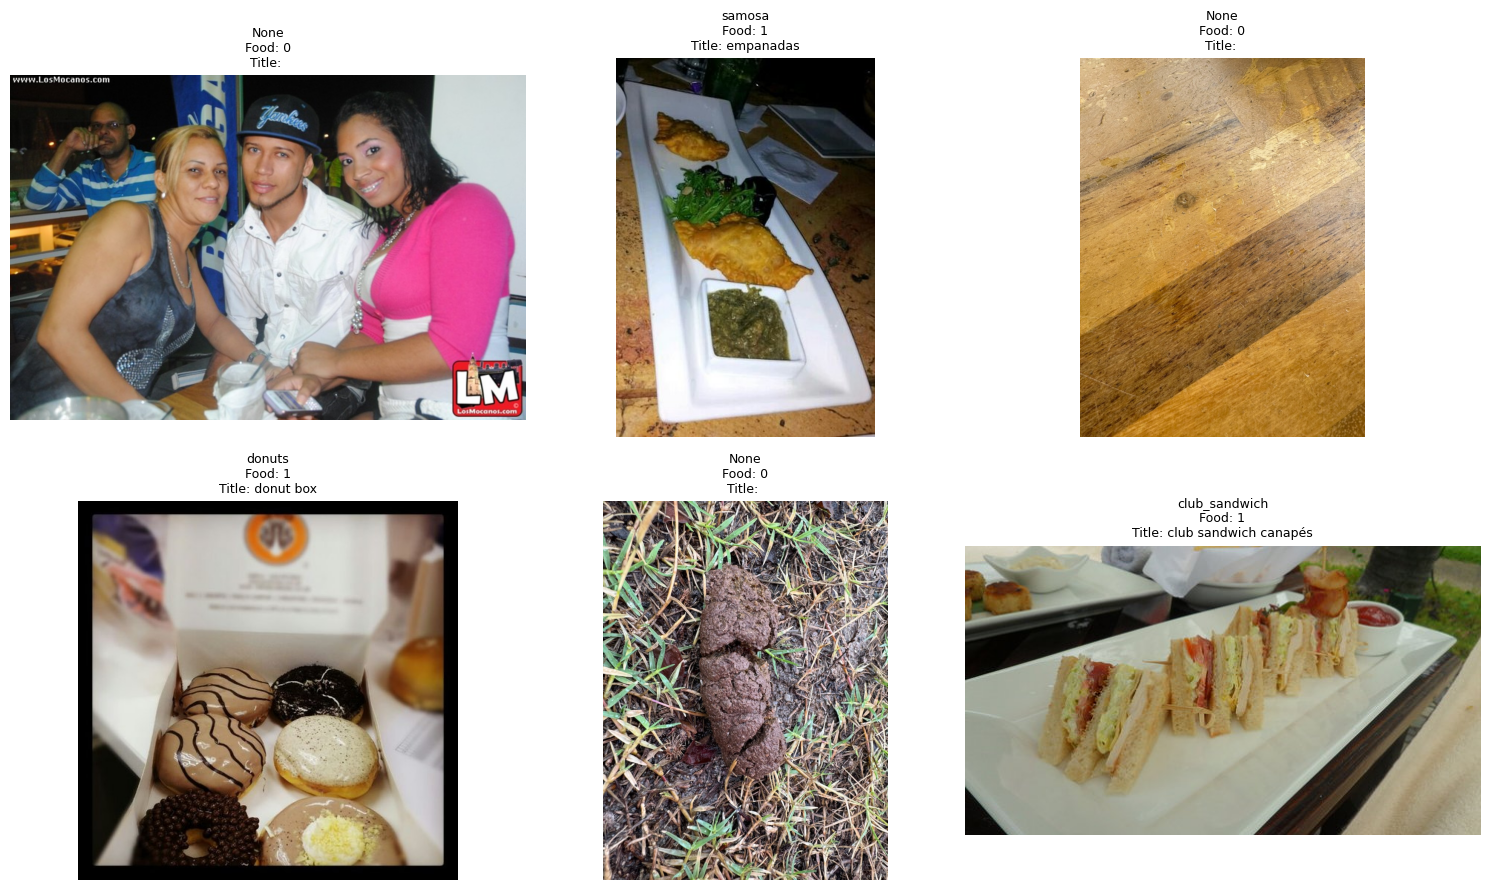

Class: None
Label: {'is_food': 0, 'image_title': '', 'food_items': [], 'drink_items': []}
Class: samosa
Label: {'is_food': 1, 'image_title': 'empanadas', 'food_items': ['green salsa', 'arugula', 'fried empanada', 'black olive'], 'drink_items': []}
Class: None
Label: {'is_food': 0, 'image_title': '', 'food_items': [], 'drink_items': []}
Class: donuts
Label: {'is_food': 1, 'image_title': 'donut box', 'food_items': ['chocolate-glazed donut with chocolate sprinkles', 'chocolate-glazed donut with chocolate drizzle', 'chocolate-glazed donut with white glaze and black specks', 'chocolate-glazed donut with white glaze and yellow sprinkles'], 'drink_items': []}
Class: None
Label: {'is_food': 0, 'image_title': '', 'food_items': [], 'drink_items': []}
Class: club_sandwich
Label: {'is_food': 1, 'image_title': 'club sandwich canapés', 'food_items': ['white bread', 'turkey slices', 'bacon strip', 'tomato slices', 'toothpick', 'egg slices'], 'drink_items': []}


In [4]:
ds = dataset["train"]

print(ds)
print("\nColumns:")
print(ds.column_names)

print("Number of samples:", len(ds))

print("\nFood distribution:")
print(ds.to_pandas()["is_food"].value_counts())

print("\nImage sources:")
print(ds.to_pandas()["image_source"].value_counts())

print("\nFood101 splits:")
print(ds.to_pandas()["food101_split"].value_counts())


df = ds.to_pandas()

df.head()


sample = ds[0]

print("Image ID:", sample["image_id"])
print("Image name:", sample["image_name"])
print("Food101 class:", sample["food101_class_name"])
print("Food101 split:", sample["food101_split"])
print("Source:", sample["image_source"])
print("Is food:", sample["is_food"])

print("\nQwen output:")
print(sample["qwen3_vl_8b_yaml_out"])

print("\nStructured label:")
print(sample["output_label_json"])

print("\nImage:")
display(sample["image"])


import matplotlib.pyplot as plt
import random

indices = random.sample(range(len(ds)), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, idx in zip(axes.flat, indices):
    sample = ds[idx]

    ax.imshow(sample["image"])
    ax.axis("off")

    label = sample["output_label_json"]

    title = (
        f"{sample['food101_class_name']}\n"
        f"Food: {label['is_food']}\n"
        f"Title: {label['image_title']}"
    )

    ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.show()

for idx in indices:
    sample = ds[idx]
    
    print("=" * 80)
    print("Class:", sample["food101_class_name"])
    print("Label:", sample["output_label_json"])

# VLM Model Candiates

We consider the following **open-weight Vision-Language Models** (VLMs) for our Feast_Vision

| Model | Parameters | Key Strength |
|---|---:|---|
| Qwen2.5-VL-3B | ~3B | Strong visual reasoning |
| Qwen2.5-VL-7B | ~7B | Strong overall capability |
| **SmolVLM-500M-Instruct** | ~500M | Lightweight and efficient |
| InternVL2.5-4B | ~4B | Strong multimodal understanding |
| LLaVA-1.5-7B | ~7B | Mature VLM ecosystem |

### Selected Model: SmolVLM-500M-Instruct

We select **SmolVLM-500M-Instruct** as our primary model because it provides
a strong **capability-to-compute trade-off**.

Its small size makes is suitable for:

- Low-cost inference and deployment
- Lower GPU (our main limitaion)
- Lower inference latency
- Efficient fine-tuning
- Potential edge on consumer-device deployment

# Setting Up the SmolVLM

In [5]:
import torch
from transformers import AutoProcessor, AutoModelForMultimodalLM

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

model.eval()

print("Model loaded successfully!")

Device: cuda


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Model loaded successfully!


# Experimetining with base SmolVLM



Image:


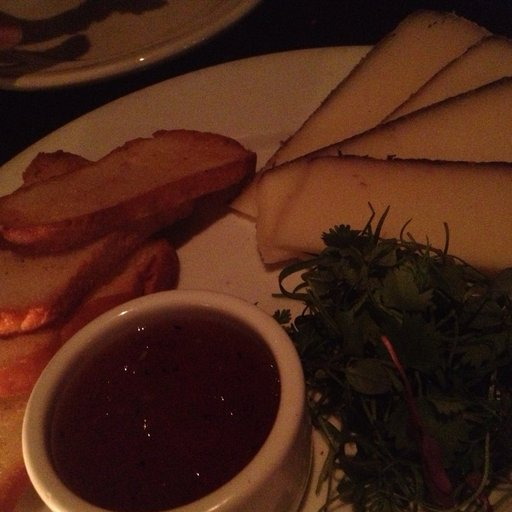

In [6]:
sample = ds[0]
print("\nImage:")
display(sample["image"])

# Prompt Methodology and Its Effect on VLM Performance

** Objective**

To understand how prompt formulation affects the performance of the VLM, three
prompting methodologies were evaluated on the same image:

1. **Normal / Direct Prompting**
2. **Descriptive / Constrained Prompting**
3. **Chain-of-Thought (CoT)-style Prompting**

The objective was to determine whether increasing the level of instruction and
reasoning improves the model's ability to identify the food items actually
present in the image.

**Reference Ground Truth**

The structured reference label for the image is:

```text
is_food: 1
image_title: cheese plate
food_items:
    - toast
    - herb garnish
    - dipping sauce
    - cheese wedge
drink_items: []

## 1.Normal Prompting

In [7]:

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {
                "type": "text",
                "text": """Look carefully at this image.

Is there food in the image?
What food items can you identify?

Return:
is_food: yes/no
food_items: item1, item2, item3
"""
            }
        ]
    }
]

# Create prompt
prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

# Prepare inputs
inputs = processor(
    text=prompt,
    images=[sample["image"]],
    return_tensors="pt"
)

# Move tensors to GPU
inputs = {
    k: v.to(model.device) if hasattr(v, "to") else v
    for k, v in inputs.items()
}

# Generate
with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False
    )

# IMPORTANT: decode full output first
generated_text = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("===== MODEL OUTPUT =====")
print(generated_text)

===== MODEL OUTPUT =====
User:




Look carefully at this image.

Is there food in the image?
What food items can you identify?

Return:
is_food: yes/no
food_items: item1, item2, item3

Assistant: Yes.


## 2.Descriptive  Prompting

In [8]:
sample = ds[0]

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {
                "type": "text",
                "text": "You are analyzing a food image.Identify the food items that are clearly visible in the image.Return ONLY a comma-separated list of food items.Do not describe the image.Do not mention plates, bowls, utensils, or decorations."
            }
        ]
    }
]

prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = processor(
    text=prompt,
    images=[sample["image"]],
    return_tensors="pt"
)

inputs = {
    k: v.to(model.device) if hasattr(v, "to") else v
    for k, v in inputs.items()
}

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False
    )

output = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print(output)

User:




You are analyzing a food image.Identify the food items that are clearly visible in the image.Return ONLY a comma-separated list of food items.Do not describe the image.Do not mention plates, bowls, utensils, or decorations.
Assistant: Fries.


## 3.Chain of Thought Prompting method

In [9]:
sample = ds[0]

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {
                "type": "text",
                "text": "You are analyzing a food image. Use chain of thought methodology before coming up any conclusion.Identify the food items that are clearly visible in the image.Return ONLY a comma-separated list of food items.Do not describe the image.Do not mention plates, bowls, utensils, or decorations."
            }
        ]
    }
]

prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = processor(
    text=prompt,
    images=[sample["image"]],
    return_tensors="pt"
)

inputs = {
    k: v.to(model.device) if hasattr(v, "to") else v
    for k, v in inputs.items()
}

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False
    )

output = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print(output)

User:




You are analyzing a food image. Use chain of thought methodology before coming up any conclusion.Identify the food items that are clearly visible in the image.Return ONLY a comma-separated list of food items.Do not describe the image.Do not mention plates, bowls, utensils, or decorations.
Assistant: Bacon, Parsley, Sauce.


## Conclusion

Even with **strong prompting strategies** like direct, constrained and CoT-style 
the VLM fails to reliably identify the correct food items.

The model shows two key failure modes:

- **Missed items:** fails to detect food items that are actually present.
- **Hallucination:** generates plausible but visually unsupported items such as
  `fries`, `bacon`, and `parsley`.

This indicates that the limitation is not simply prompt quality but **weak
visual grounding**. Therefore, improving performance requires
moving beyond prompt engineering

# Setting up our Pretrained Multi-Class Efficient_Net based classifer

In [10]:
!pip install -q gdown

import gdown
import os

file_id = "1d7tKkgWC0lLooULNYTg_qCLGHbtf98ie"

model_path = "/kaggle/working/model.keras"

gdown.download(
    id=file_id,
    output=model_path,
    quiet=False
)

print("Model exists:", os.path.exists(model_path))
print("Model size:", os.path.getsize(model_path) / (1024**2), "MB")

Downloading...
From (original): https://drive.google.com/uc?id=1d7tKkgWC0lLooULNYTg_qCLGHbtf98ie
From (redirected): https://drive.google.com/uc?id=1d7tKkgWC0lLooULNYTg_qCLGHbtf98ie&confirm=t&uuid=57407a6a-bd39-403a-9619-88fbb8eb8b0f
To: /kaggle/working/model.keras
100%|██████████| 135M/135M [00:01<00:00, 92.0MB/s]

Model exists: True
Model size: 128.50094032287598 MB


In [11]:
import tensorflow as tf

efficientnet_model = tf.keras.models.load_model(model_path)

print("Model loaded successfully!")
efficientnet_model.summary()

I0000 00:00:1788418756.667170      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10788 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788418756.669715      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 12860 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model loaded successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 604 variables whereas the saved optimizer has 608 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb1 (Functional)     │ (None, 7, 7, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 101)            │       129,381 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_1 (Cast)                   │ (None, 101)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,989,752 (76.25 MB)

 Trainable params: 6,642,565 (25.34 MB)

 Non-trainable params: 62,055 (242.41 KB)

 Optimizer params: 13,285,132 (50.68 MB)

In [12]:
import tensorflow as tf
import numpy as np


# ============================================================
# FOOD-101 CLASS NAMES
# ============================================================

class_names = [
    'apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio',
    'beef_tartare', 'beet_salad', 'beignets', 'bibimbap',
    'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad',
    'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheesecake',
    'cheese_plate', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings',
    'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder',
    'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame',
    'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame',
    'eggs_benedict', 'escargots', 'falafel', 'filet_mignon',
    'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup',
    'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt',
    'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich',
    'grilled_salmon', 'guacamole', 'gyoza', 'hamburger',
    'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus',
    'ice_cream', 'lasagna', 'lobster_bisque', 'lobster_roll_sandwich',
    'macaroni_and_cheese', 'macarons', 'miso_soup', 'mussels', 'nachos',
    'omelette', 'onion_rings', 'oysters', 'pad_thai', 'paella', 'pancakes',
    'panna_cotta', 'peking_duck', 'pho', 'pizza', 'pork_chop', 'poutine',
    'prime_rib', 'pulled_pork_sandwich', 'ramen', 'ravioli',
    'red_velvet_cake', 'risotto', 'samosa', 'sashimi', 'scallops',
    'seaweed_salad', 'shrimp_and_grits', 'spaghetti_bolognese',
    'spaghetti_carbonara', 'spring_rolls', 'steak', 'strawberry_shortcake',
    'sushi', 'tacos', 'takoyaki', 'tiramisu', 'tuna_tartare', 'waffles'
]


# ============================================================
# EFFICIENTNET PREDICTION FUNCTION
# ============================================================

def get_high_confidence_classes(
    image,
    efficientnet_model,
    class_names,
    threshold=0.90
):
    """
    Input:
        image       : decoded image (e.g. sample["image"])
        model       : trained EfficientNet model
        class_names : Food-101 class-name vector
        threshold   : probability threshold

    Returns:
        Dictionary containing only classes whose
        predicted probability is > threshold.
    """

    # --------------------------------------------------------
    # 1. Convert image to TensorFlow tensor
    # --------------------------------------------------------

    image = tf.convert_to_tensor(image)


    # --------------------------------------------------------
    # 2. Resize exactly like training preprocessing
    # --------------------------------------------------------

    image = tf.image.resize(
        image,
        [224, 224]
    )

    image.set_shape([224, 224, 3])


    # --------------------------------------------------------
    # 3. IMPORTANT:
    # Keep scale=False
    # --------------------------------------------------------

    # No /255 normalization here.


    # --------------------------------------------------------
    # 4. Add batch dimension
    # --------------------------------------------------------

    image_batch = tf.expand_dims(
        image,
        axis=0
    )


    # --------------------------------------------------------
    # 5. EfficientNet prediction
    # --------------------------------------------------------

    prediction = efficientnet_model.predict(
        image_batch,
        verbose=0
    )


    # --------------------------------------------------------
    # 6. Get probability vector
    # --------------------------------------------------------

    probabilities = prediction[0]


    # --------------------------------------------------------
    # 7. Sanity check
    # --------------------------------------------------------

    if len(probabilities) != len(class_names):
        raise ValueError(
            f"Model outputs {len(probabilities)} classes, "
            f"but class_names contains {len(class_names)} classes."
        )


    # --------------------------------------------------------
    # 8. Class → probability mapping
    # --------------------------------------------------------

    class_probability_vector = {
        class_name: float(probability)
        for class_name, probability in zip(
            class_names,
            probabilities
        )
    }


    # --------------------------------------------------------
    # 9. Keep ONLY classes > threshold
    # --------------------------------------------------------

    high_confidence_classes = {
        class_name: probability
        for class_name, probability in class_probability_vector.items()
        if probability > threshold
    }


    # --------------------------------------------------------
    # 10. Sort highest probability → lowest
    # --------------------------------------------------------

    high_confidence_classes = dict(
        sorted(
            high_confidence_classes.items(),
            key=lambda x: x[1],
            reverse=True
        )
    )


    return high_confidence_classes

# Combining VLM and Efficinet_Net
 To counter the hallucination we will utlize our pretrained Image Classifier And see how will it perform this time
 # EfficientNet-Grounded VLM Pipeline
 **Overall Architecture**

```text
                         Input Image
                              │
                              ▼
                    ┌──────────────────┐
                    │ Image Preprocess │
                    │   Resize 224×224 │
                    │   No /255 scale  │
                    └────────┬─────────┘
                             │
                             ▼
                    ┌──────────────────┐
                    │   EfficientNet   │
                    │      B0          │
                    │   Food-101       │
                    └────────┬─────────┘
                             │
                             ▼
                   101-Class Probability
                         Vector
                             │
                             ▼
                    ┌──────────────────┐
                    │ Confidence Filter│
                    │    P > 0.90      │
                    └────────┬─────────┘
                             │
                  ┌──────────┴──────────┐
                  │                     │
              Classes Found         No Class
              P > 0.90              P > 0.90
                  │                     │
                  ▼                     ▼
          Classifier Grounding    No Classifier
               Context              Grounding
                  │                     │
                  └──────────┬──────────┘
                             │
                             ▼
                    ┌──────────────────┐
                    │       VLM        │
                    │  Image + Ground  │
                    │    Information   │
                    └────────┬─────────┘
                             │
                             ▼
                    Grounded VLM Output
                             │
                             ▼
                  ┌─────────────────────┐
                  │ is_food              │
                  │ food_items           │
                  └─────────────────────┘

In [13]:
# ============================================================
# EFFICIENTNET → VLM GROUNDING
# ============================================================

THRESHOLD = 0.90

# ------------------------------------------------------------
# 1. Get EfficientNet high-confidence predictions
# ------------------------------------------------------------

high_confidence_classes = get_high_confidence_classes(
    sample["image"],
    efficientnet_model,
    class_names,
    THRESHOLD
)


# ------------------------------------------------------------
# 2. Display EfficientNet grounding
# ------------------------------------------------------------

print("=" * 60)
print("EFFICIENTNET GROUNDING")
print("=" * 60)

if high_confidence_classes:

    for class_name, score in high_confidence_classes.items():
        print(
            f"{class_name:<30} "
            f"{score:.6f} "
            f"({score:.2%})"
        )

else:

    print("No class has confidence > 0.90")


# ------------------------------------------------------------
# 3. Create classifier guidance for VLM
# ------------------------------------------------------------

if high_confidence_classes:

    classifier_predictions = "\n".join(
        f"- {class_name}: {score:.2%}"
        for class_name, score in high_confidence_classes.items()
    )

    classifier_guidance = f"""
An image classifier has identified the following
high-confidence food class(es):

{classifier_predictions}

Use these classifier predictions as visual grounding.

The classifier predictions are strong visual evidence.
Prefer these food categories when describing the image
and do not arbitrarily replace them with unrelated
food categories.

However, only describe food that is actually visually
supported by the image.
"""

else:

    classifier_guidance = """
The image classifier did not identify any food class
with confidence greater than 90%.

Do not rely on classifier grounding.
Inspect the image carefully and identify only food items
that are visually supported.
"""


# ------------------------------------------------------------
# 4. VLM PROMPT
# ------------------------------------------------------------

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {
                "type": "text",
                "text": f"""
Look carefully at this image.

{classifier_guidance}

Answer:

is_food: yes/no
food_items: item1, item2, item3

Do not invent food items that are not visually supported.
"""
            }
        ]
    }
]


# ------------------------------------------------------------
# 5. Prepare VLM input
# ------------------------------------------------------------

prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True
)

inputs = processor(
    text=prompt,
    images=[sample["image"]],
    return_tensors="pt"
)


# ------------------------------------------------------------
# 6. Move inputs to VLM device
# ------------------------------------------------------------

inputs = {
    k: v.to(model.device) if hasattr(v, "to") else v
    for k, v in inputs.items()
}


# ------------------------------------------------------------
# 7. Generate VLM response
# ------------------------------------------------------------

with torch.no_grad():

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False
    )


# ------------------------------------------------------------
# 8. Decode VLM output
# ------------------------------------------------------------

generated_text = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]


# ------------------------------------------------------------
# 9. Display final result
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("GROUNDED VLM OUTPUT")
print("=" * 60)

print(generated_text)

I0000 00:00:1788418790.438056     127 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


EFFICIENTNET GROUNDING
cheese_plate                   0.999340 (99.93%)

GROUNDED VLM OUTPUT
User:





Look carefully at this image.


An image classifier has identified the following
high-confidence food class(es):

- cheese_plate: 99.93%

Use these classifier predictions as visual grounding.

The classifier predictions are strong visual evidence.
Prefer these food categories when describing the image
and do not arbitrarily replace them with unrelated
food categories.

However, only describe food that is actually visually
supported by the image.


Answer:

is_food: yes/no
food_items: item1, item2, item3

Do not invent food items that are not visually supported.

Assistant: Cheese plate.


## Overall Conclusion So Far

The hallucination problem has been **partially addressed** by introducing the pretrained EfficientNet classifier as a high-confidence grounding mechanism for the VLM. This helps constrain the VLM's food-category predictions and reduces unsupported or unrelated food identifications.

However, the current approach has an important limitation: **it identifies the overall food category but does not reliably identify the individual constituents/components of the food**.

For example:

> **EfficientNet:** `pizza (96%)`  
> **VLM:** `pizza` ✓  
> **Constituents:** cheese, tomato sauce, toppings, etc. ✗/inconsistent

Thus, the current system improves **food-level grounding**, but **constituent-level understanding remains an open problem**.

### Current Status

**✓ Addressed to some extent:** VLM food-category hallucination  
**✗ Not yet solved:** Food constituent/component identification

The next research direction is therefore to extend the classifier-grounded VLM from **category-level grounding → constituent-level grounding**.

In [14]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("PyTorch CUDA:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU capability:", torch.cuda.get_device_capability(0))
!nvidia-smi

    

PyTorch: 2.10.0+cu128
CUDA available: True
PyTorch CUDA: 12.8
GPU: Tesla T4
GPU capability: (7, 5)
Thu Sep  3 07:00:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P0             38W /   70W |    3351MiB /  15360MiB |      1%      Default |
|                                        